In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/banks_financial_health_clean.csv")
df.head()

,number,bank_name,assets,loans,liabilities,deposits,equity,net_income,year
0,1.0,"""Halyk Bank of Kazakhstan"", JSC",1.386279e+10,8.087488e+09,1.197611e+10,5.137146e+09,1.886682e+09,539280069.0,2023
1,2.0,"""Kaspi Bank"", JSC",5.086784e+09,3.380025e+09,4.542690e+09,3.699473e+09,5.440944e+08,361709053.0,2023
2,3.0,"""Bank CenterCredit"", JSC",4.346623e+09,2.161666e+09,4.072048e+09,1.888551e+09,2.745749e+08,145004425.0,2023
3,4.0,"""Otbasy bank"", JSC",3.440105e+09,2.984578e+09,2.977844e+09,2.187315e+09,4.622612e+08,96035130.0,2023
4,5.0,"""ForteBank"", JSC",2.914127e+09,1.275637e+09,2.586495e+09,7.761670e+08,3.276314e+08,92904022.0,2023


In [2]:
# ROA = Net Income / Assets
df["ROA"] = df["net_income"] / df["assets"]

# ROE = Net Income / Equity
df["ROE"] = df["net_income"] / df["equity"]

# Loan-to-Deposit Ratio = Loans / Deposits
df["LDR"] = df["loans"] / df["deposits"]

# Equity-to-Assets Ratio = Equity / Assets
df["EAR"] = df["equity"] / df["assets"]

df[["bank_name", "year", "ROA", "ROE", "LDR", "EAR"]].head(10)

,bank_name,year,ROA,ROE,LDR,EAR
0,"""Halyk Bank of Kazakhstan"", JSC",2023,0.038901,0.285835,1.574315,0.136097
1,"""Kaspi Bank"", JSC",2023,0.071108,0.664791,0.913650,0.106962
2,"""Bank CenterCredit"", JSC",2023,0.033360,0.528105,1.144616,0.063170
3,"""Otbasy bank"", JSC",2023,0.027916,0.207751,1.364494,0.134374
4,"""ForteBank"", JSC",2023,0.031881,0.283563,1.643508,0.112429
5,"""First Heartland Jusan Bank"", JSC",2023,0.029020,0.158031,1.748847,0.183635
6,"""Eurasian Bank"", JSC",2023,0.034992,0.422520,1.348792,0.082817
7,"""Bank RBK"" Bank"", JSC",2023,0.019495,0.318161,2.044227,0.061274
8,"""Bereke Bank"", JSC",2023,-0.076095,-0.986133,6.438480,0.077165
9,"""Citibank Kazakhstan"", JSC",2023,0.075071,0.758300,39765.961391,0.098999


In [3]:
# Топ банков по ROA в 2023
top_roa = df[df["year"] == 2023].sort_values("ROA", ascending=False)
top_roa[["bank_name", "ROA", "ROE", "LDR", "EAR"]].head(5)

,bank_name,ROA,ROE,LDR,EAR
9,"""Citibank Kazakhstan"", JSC",0.075071,0.758300,39765.961391,0.098999
1,"""Kaspi Bank"", JSC",0.071108,0.664791,0.913650,0.106962
19,"""Al-Hilal"" Islamic Bank"", JSC",0.051774,0.148651,16.238247,0.348296
15,"""Industrial and Commercial Bank of China in Al...",0.044202,0.261059,0.914194,0.169316
0,"""Halyk Bank of Kazakhstan"", JSC",0.038901,0.285835,1.574315,0.136097


In [4]:
df.to_csv("../data/processed/banks_with_ratios.csv", index=False)
print("Сохранено!")

Сохранено!


Matplotlib is building the font cache; this may take a moment.
/var/folders/vs/h0vscb8x3rl31xnrq4jgmgrh0000gn/T/ipykernel_39405/11226412.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2023, x="ROA", y="bank_name", palette="Blues_r")


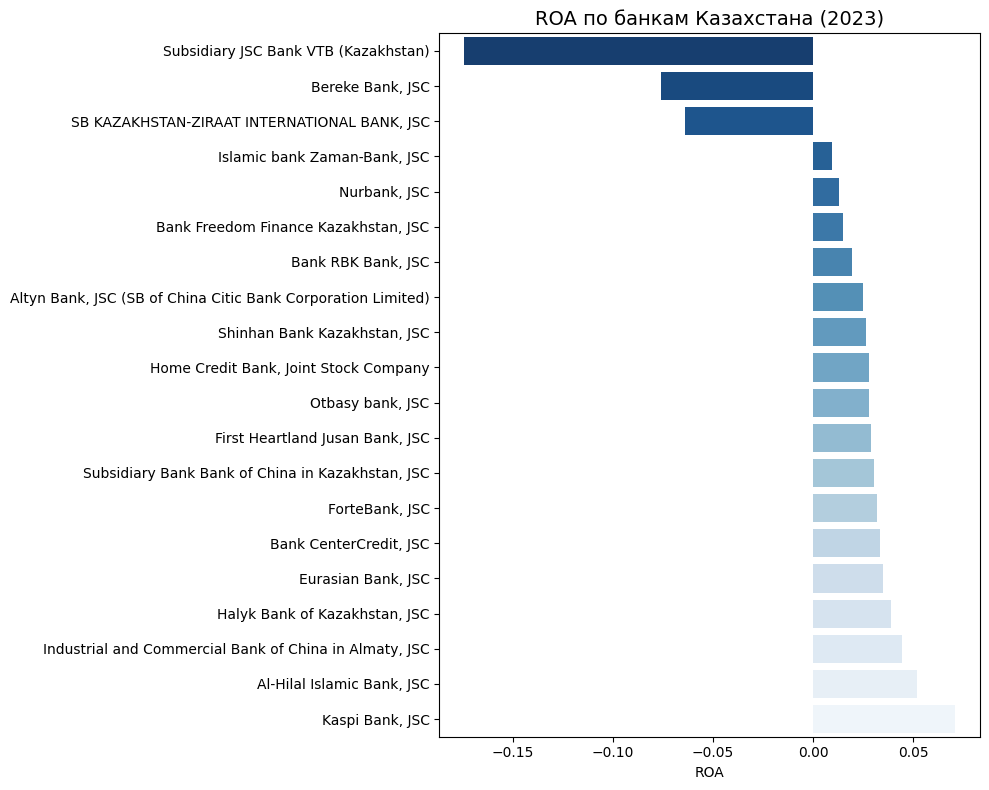

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берём 2023 год, сортируем по ROA, убираем аномальный Citibank
df_2023 = df[df["year"] == 2023].copy()
df_2023 = df_2023[df_2023["LDR"] < 100]  # убираем аномалии
df_2023 = df_2023.sort_values("ROA", ascending=True)

# Очищаем названия банков от лишних кавычек
df_2023["bank_name"] = df_2023["bank_name"].str.replace('"', '').str.strip()

plt.figure(figsize=(10, 8))
sns.barplot(data=df_2023, x="ROA", y="bank_name", palette="Blues_r")
plt.title("ROA по банкам Казахстана (2023)", fontsize=14)
plt.xlabel("ROA")
plt.ylabel("")
plt.tight_layout()
plt.show()

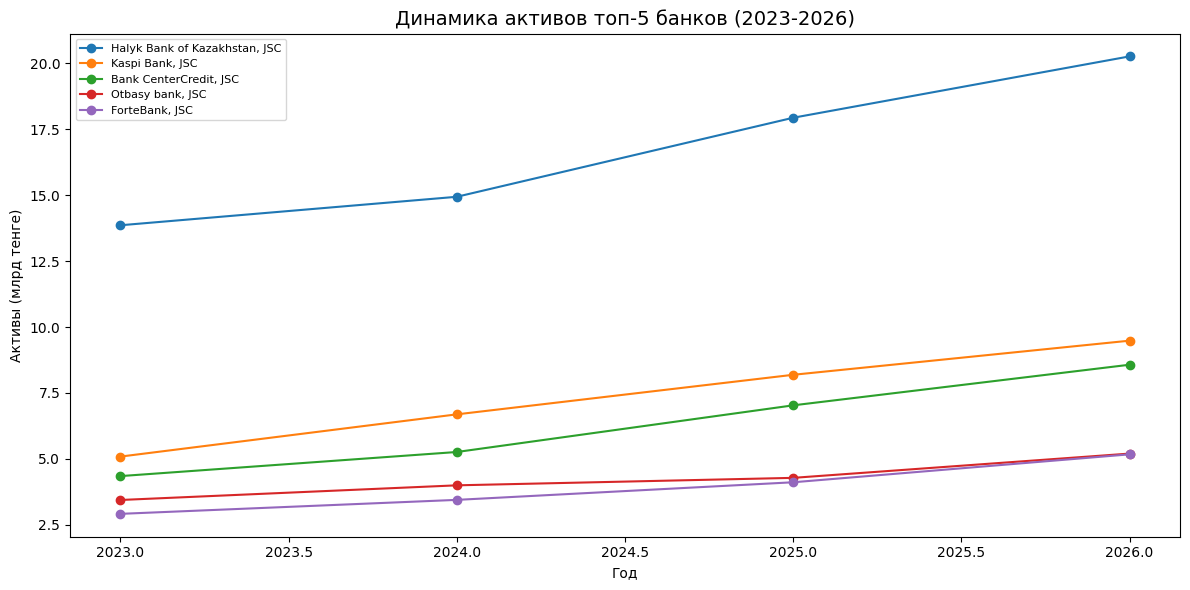

In [6]:
# Топ-5 банков по активам в 2023
top5_banks = df_2023.sort_values("assets", ascending=False).head(5)["bank_name"].tolist()

# Фильтруем данные по этим банкам
df["bank_name"] = df["bank_name"].str.replace('"', '').str.strip()
df_top5 = df[df["bank_name"].isin(top5_banks)]

plt.figure(figsize=(12, 6))
for bank in top5_banks:
    data = df_top5[df_top5["bank_name"] == bank]
    plt.plot(data["year"], data["assets"] / 1e9, marker="o", label=bank)

plt.title("Динамика активов топ-5 банков (2023-2026)", fontsize=14)
plt.xlabel("Год")
plt.ylabel("Активы (млрд тенге)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()